# Logistic Regression Classification on Ecommerce Data

This notebook demonstrates a **classification use case** using **Logistic Regression**.

## Objective
Predict whether an order is **returned (1)** or **not returned (0)** based on ecommerce order features.

## Dataset
- 1000 rows
- 10 columns
- Mix of categorical and numerical features

## Target Column
- `returned`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

df = pd.read_csv('ecommerce_classification_data.csv')
df.head()


,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating,returned
0,10001,Beauty,Loyal,Wallet,South,504.45,4,9.42,4.3,0
1,10002,Sports,Returning,Card,West,3168.36,4,6.95,3.2,0
2,10003,Home,Returning,Card,East,4908.71,4,27.42,3.3,0
3,10004,Sports,Loyal,Wallet,West,1072.02,2,31.82,2.8,0
4,10005,Sports,Returning,COD,West,3994.09,5,12.96,4.1,0


## 1. Basic exploration

In [2]:
df.head()

,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating,returned
0,10001,Beauty,Loyal,Wallet,South,504.45,4,9.42,4.3,0
1,10002,Sports,Returning,Card,West,3168.36,4,6.95,3.2,0
2,10003,Home,Returning,Card,East,4908.71,4,27.42,3.3,0
3,10004,Sports,Loyal,Wallet,West,1072.02,2,31.82,2.8,0
4,10005,Sports,Returning,COD,West,3994.09,5,12.96,4.1,0


In [3]:
df.tail()

,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating,returned
995,10996,Fashion,Returning,Card,North,476.09,4,12.60,4.4,0
996,10997,Electronics,Returning,UPI,North,3035.01,5,16.73,3.2,1
997,10998,Electronics,Returning,Card,South,3733.50,3,12.43,2.8,0
998,10999,Beauty,New,UPI,East,307.35,3,23.89,3.1,0
999,11000,Home,New,Card,East,3344.78,4,23.18,4.8,1


In [4]:
df.shape

(1000, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   int64  
 1   product_category  1000 non-null   str    
 2   customer_segment  1000 non-null   str    
 3   payment_method    1000 non-null   str    
 4   region            1000 non-null   str    
 5   unit_price        1000 non-null   float64
 6   quantity          1000 non-null   int64  
 7   discount_percent  1000 non-null   float64
 8   customer_rating   1000 non-null   float64
 9   returned          1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 99.0 KB


In [6]:
df.describe()

,order_id,unit_price,quantity,discount_percent,customer_rating,returned
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,10500.500000,2566.966320,3.067000,17.43165,3.741700,0.204000
std,288.819436,1395.981531,1.398738,10.11247,0.732849,0.403171
min,10001.000000,150.060000,1.000000,0.01000,2.500000,0.000000
25%,10250.750000,1350.395000,2.000000,9.00750,3.100000,0.000000
50%,10500.500000,2585.060000,3.000000,16.88000,3.700000,0.000000
75%,10750.250000,3779.562500,4.000000,26.29250,4.400000,0.000000
max,11000.000000,4997.850000,5.000000,34.96000,5.000000,1.000000


## 2. Prepare features and target

In [7]:
y = df["returned"]

X = df.drop("returned", axis=1)

X.head()

,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating
0,10001,Beauty,Loyal,Wallet,South,504.45,4,9.42,4.3
1,10002,Sports,Returning,Card,West,3168.36,4,6.95,3.2
2,10003,Home,Returning,Card,East,4908.71,4,27.42,3.3
3,10004,Sports,Loyal,Wallet,West,1072.02,2,31.82,2.8
4,10005,Sports,Returning,COD,West,3994.09,5,12.96,4.1


In [8]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: returned, dtype: int64

## 3. Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape

(800, 9)

In [11]:
X_test.shape

(200, 9)

In [12]:
y_train.shape

(800,)

In [13]:
y_test.shape

(200,)

## 4. Build preprocessing + Logistic Regression pipeline

In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


C:\Users\Nallabothula.Naidu\AppData\Local\Temp\ipykernel_30456\3855590836.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [15]:
numerical_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])



In [16]:
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_pipeline, categorical_cols),
    ("num", numerical_pipeline, numerical_cols)
])


In [17]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

## 5. Predictions and evaluation

In [18]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]








In [19]:
accuracy_score(y_test, y_pred)

0.81

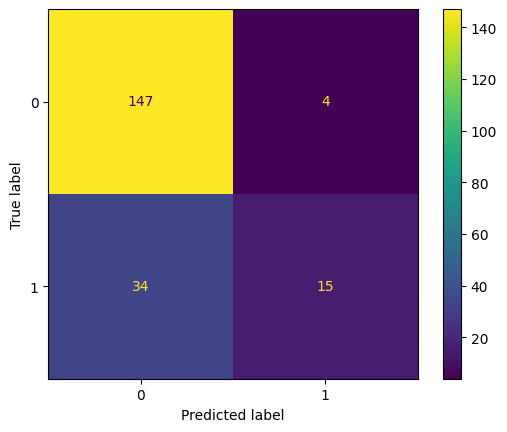

In [20]:
cm = confusion_matrix(y_test, y_pred)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [21]:
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.81      0.97      0.89       151
           1       0.79      0.31      0.44        49

    accuracy                           0.81       200
   macro avg       0.80      0.64      0.66       200
weighted avg       0.81      0.81      0.78       200



In [22]:
roc_auc_score(y_test, y_pred_proba)


0.7068522773347751

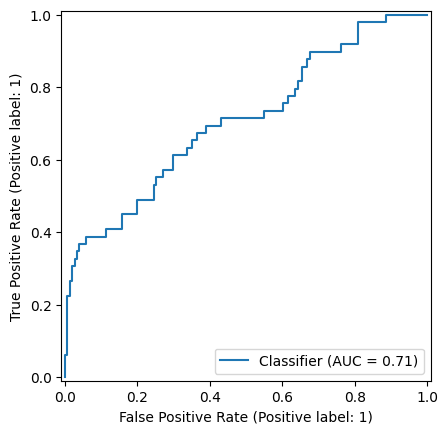

In [23]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.show()

## 6. Predict on sample new records

In [24]:
sample_new = pd.DataFrame([
    {
        "order_id": 20001,
        "product_category": "Beauty",
        "customer_segment": "Loyal",
        "payment_method": "Wallet",
        "region": "South",
        "unit_price": 500.00,
        "quantity": 3,
        "discount_percent": 10.00,
        "customer_rating": 4.2
    },
    {
        "order_id": 20002,
        "product_category": "Electronics",
        "customer_segment": "Returning",
        "payment_method": "Card",
        "region": "West",
        "unit_price": 3200.00,
        "quantity": 1,
        "discount_percent": 25.00,
        "customer_rating": 3.0
    }
])

sample_new


,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating
0,20001,Beauty,Loyal,Wallet,South,500.0,3,10.0,4.2
1,20002,Electronics,Returning,Card,West,3200.0,1,25.0,3.0


In [25]:
sample_pred = model.predict(sample_new)
sample_pred

sample_pred_proba = model.predict_proba(sample_new)[:, 1]
sample_pred_proba

array([0.06860828, 0.61214152])

## 7. Feature importance insight

For logistic regression, coefficients help us understand the direction of impact.


In [26]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coeffs = model.named_steps["classifier"].coef_[0]

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coeffs
})

feat_imp["Abs_Coefficient"] = np.abs(feat_imp["Coefficient"])
feat_imp = feat_imp.sort_values(by="Abs_Coefficient", ascending=False)

feat_imp.head(20)

,Feature,Coefficient,Abs_Coefficient
5,cat__customer_segment_Loyal,-0.967639,0.967639
6,cat__customer_segment_New,0.813802,0.813802
8,cat__payment_method_COD,0.748280,0.748280
19,num__discount_percent,0.607744,0.607744
9,cat__payment_method_Card,-0.528212,0.528212
1,cat__product_category_Electronics,0.528076,0.528076
20,num__customer_rating,-0.524893,0.524893
13,cat__region_North,0.453540,0.453540
14,cat__region_South,-0.388847,0.388847
18,num__quantity,0.360945,0.360945


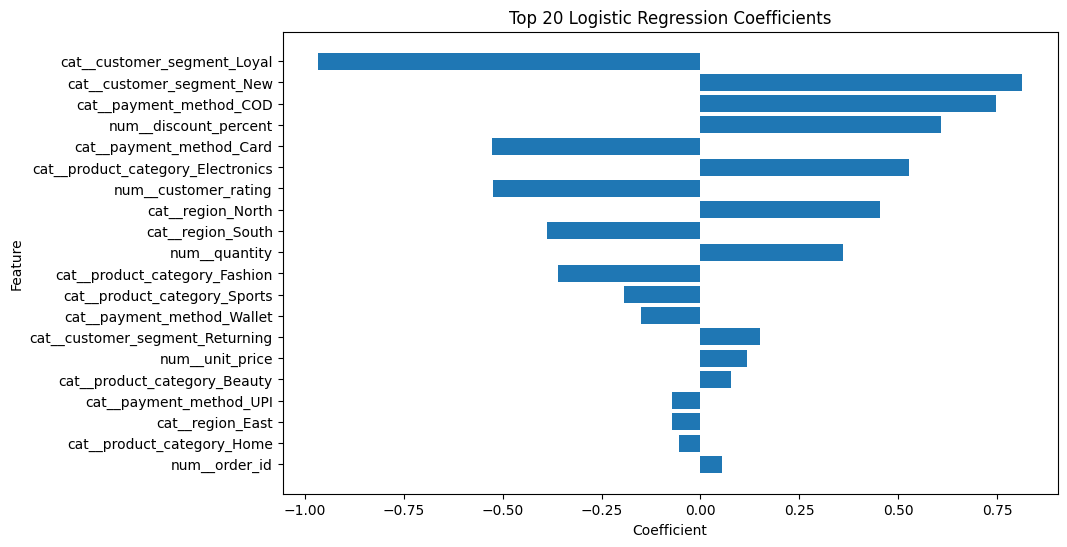

In [27]:
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"].head(20)[::-1], feat_imp["Coefficient"].head(20)[::-1])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Logistic Regression Coefficients")
plt.show()